# DHCF vs DOSAGE-DHCF on CiteULike-A

Same controlled comparison as the MovieLens-100K notebook, now on CiteULike-A — the second benchmark used in the DHCF paper (KDD 2020).

**Dataset:** 5,551 users (CiteULike users), 16,980 items (scientific papers), ~205,000 binary interactions. Implicit feedback only.

**Eval:** matching DHCF paper, full-ranking Recall@K and NDCG@K for K ∈ {10, 20, 50}.

**Configurations (we keep this tight — 2 DOSAGE runs only):**
1. **DHCF (baseline):** hyperedges = item-derived (each item is a hyperedge of its users), interaction-matrix-derived.
2. **DOSAGE-DHCF Run A:** small hyperedges (best from ML-100K).
3. **DOSAGE-DHCF Run B:** stats-matching (more, larger hyperedges, low-membership P2 seeding).

Runtime budget: ~20-40 min on Kaggle T4.

In [1]:
!pip install -q networkx scipy tqdm

In [2]:
import os, math, time, urllib.request, random
from collections import defaultdict, Counter
import numpy as np
import scipy.sparse as sp
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## 1. Download CiteULike-A and parse

Format of `users.dat`: one line per user. First int = number of items, rest = item ids (space-separated). User id = line number.

In [3]:
USERS_PATH = '/kaggle/working/users.dat'
if not os.path.exists(USERS_PATH):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/js05212/citeulike-a/master/users.dat', USERS_PATH)

rows = []
with open(USERS_PATH) as f:
    for u_idx, line in enumerate(f):
        parts = line.strip().split()
        if not parts: continue
        item_ids = parts[1:]  # parts[0] is count
        for it in item_ids:
            rows.append((u_idx, int(it)))
print(f'Raw interactions: {len(rows)}')

# 5-core filter (DHCF paper preprocessing)
u_cnt, i_cnt = Counter(u for u,_ in rows), Counter(i for _,i in rows)
rows = [(u,i) for u,i in rows if u_cnt[u]>=5 and i_cnt[i]>=5]
u_ids = sorted({u for u,_ in rows}); i_ids = sorted({i for _,i in rows})
u_map = {u:k for k,u in enumerate(u_ids)}; i_map = {i:k for k,i in enumerate(i_ids)}
rows = [(u_map[u], i_map[i]) for u,i in rows]
n_users, n_items = len(u_ids), len(i_ids)
print(f'After 5-core: Users={n_users}  Items={n_items}  Interactions={len(rows)}')
print(f'Avg user activity: {len(rows)/n_users:.1f} items/user')
print(f'Avg item popularity: {len(rows)/n_items:.1f} users/item')

Raw interactions: 204986
After 5-core: Users=5550  Items=15439  Interactions=200251
Avg user activity: 36.1 items/user
Avg item popularity: 13.0 users/item


In [4]:
# Per-user 80/20 split
by_user = defaultdict(list)
for u,i in rows: by_user[u].append(i)
train_pairs, test_by_user = [], {}
rng = random.Random(SEED)
for u, items in by_user.items():
    rng.shuffle(items)
    n_test = max(1, int(0.2*len(items)))
    test_by_user[u] = set(items[:n_test])
    for i in items[n_test:]: train_pairs.append((u,i))
train_user_pos = defaultdict(set)
for u,i in train_pairs: train_user_pos[u].add(i)
print(f'Train: {len(train_pairs)}   Test users: {len(test_by_user)}')

Train: 162285   Test users: 5550


## 2. Build the original DHCF hypergraphs

`H_ui` = each item is a hyperedge of its users. `H_iu = H_ui.T`.

In [5]:
rows_u = np.array([u for u,_ in train_pairs], dtype=np.int32)
cols_i = np.array([i for _,i in train_pairs], dtype=np.int32)
H_ui_orig_sp = sp.coo_matrix((np.ones(len(train_pairs), dtype=np.float32), (rows_u, cols_i)),
                              shape=(n_users, n_items)).tocsr()
H_iu_orig_sp = H_ui_orig_sp.T.tocsr()
print(f'H_ui (DHCF orig): shape={H_ui_orig_sp.shape}, nnz={H_ui_orig_sp.nnz}')
print(f'H_iu (DHCF orig): shape={H_iu_orig_sp.shape}, nnz={H_iu_orig_sp.nnz}')

H_ui (DHCF orig): shape=(5550, 15439), nnz=162285
H_iu (DHCF orig): shape=(15439, 5550), nnz=162285


## 3. Build collab graphs (user-user, item-item) with KNN-augmentation

For CiteULike-A (sparser than ML-100K), `MIN_SHARED=2` is appropriate — many user pairs share only 1-2 items in this domain.

In [6]:
MIN_SHARED_USER = 2
MIN_SHARED_ITEM = 2
KNN_AUGMENT_K = 10

# user-user co-occurrence
item_users = defaultdict(set)
for u,i in train_pairs: item_users[i].add(u)
shared_uu = defaultdict(int)
for item, users in tqdm(item_users.items(), desc='count uu shared'):
    users = list(users)
    for i in range(len(users)):
        for j in range(i+1, len(users)):
            shared_uu[(min(users[i],users[j]), max(users[i],users[j]))] += 1

uu_nbrs = defaultdict(list)
for (a,b), c in shared_uu.items():
    uu_nbrs[a].append((b, c)); uu_nbrs[b].append((a, c))

G_user = nx.Graph(); G_user.add_nodes_from(range(n_users))
for (a,b), c in shared_uu.items():
    if c >= MIN_SHARED_USER: G_user.add_edge(a, b)
iso_before = sum(1 for n,d in G_user.degree() if d == 0)
augmented = 0
for u in range(n_users):
    if G_user.degree(u) >= KNN_AUGMENT_K: continue
    top = sorted(uu_nbrs[u], key=lambda x: -x[1])[:KNN_AUGMENT_K]
    for v, _ in top:
        if not G_user.has_edge(u, v):
            G_user.add_edge(u, v); augmented += 1
iso_u = sum(1 for n,d in G_user.degree() if d == 0)
print(f'G_user: {G_user.number_of_nodes()} nodes, {G_user.number_of_edges()} edges, iso_before={iso_before} iso_after_KNN={iso_u}, KNN_added={augmented}')

count uu shared: 100%|██████████| 15439/15439 [00:01<00:00, 9898.08it/s] 


G_user: 5550 nodes, 254232 edges, iso_before=15 iso_after_KNN=7, KNN_added=1323


In [7]:
# item-item co-occurrence
user_items = defaultdict(set)
for u,i in train_pairs: user_items[u].add(i)
shared_ii = defaultdict(int)
for u, items in tqdm(user_items.items(), desc='count ii shared'):
    items = list(items)
    for i in range(len(items)):
        for j in range(i+1, len(items)):
            shared_ii[(min(items[i],items[j]), max(items[i],items[j]))] += 1

ii_nbrs = defaultdict(list)
for (a,b), c in shared_ii.items():
    ii_nbrs[a].append((b, c)); ii_nbrs[b].append((a, c))

G_item = nx.Graph(); G_item.add_nodes_from(range(n_items))
for (a,b), c in shared_ii.items():
    if c >= MIN_SHARED_ITEM: G_item.add_edge(a, b)
iso_before = sum(1 for n,d in G_item.degree() if d == 0)
augmented = 0
for u in range(n_items):
    if G_item.degree(u) >= KNN_AUGMENT_K: continue
    top = sorted(ii_nbrs[u], key=lambda x: -x[1])[:KNN_AUGMENT_K]
    for v, _ in top:
        if not G_item.has_edge(u, v):
            G_item.add_edge(u, v); augmented += 1
iso_i = sum(1 for n,d in G_item.degree() if d == 0)
print(f'G_item: {G_item.number_of_nodes()} nodes, {G_item.number_of_edges()} edges, iso_before={iso_before} iso_after_KNN={iso_i}, KNN_added={augmented}')

count ii shared: 100%|██████████| 5543/5543 [00:05<00:00, 970.81it/s] 


G_item: 15439 nodes, 815080 edges, iso_before=103 iso_after_KNN=0, KNN_added=6646


## 4. DOSAGE primitives + `DOSAGE_TWO_PHASE` (verbatim from main notebook)

In [8]:
stats = {'subsets_checked':0,'density_calls':0,'distance_calls':0,'objective_calls':0}

def DENSITY(G):
    if G.number_of_nodes() == 0: return 0
    return G.number_of_edges() / G.number_of_nodes()

def DISTANCE(G1, G2):
    U, Z = set(G1.nodes()), set(G2.nodes())
    if not U or not Z: return 2
    if U == Z: return 0
    return 2 - (len(U & Z) ** 2) / (len(U) * len(Z))

def OBJECTIVE(W, lam):
    td = sum(DENSITY(g) for g in W)
    tdist = sum(DISTANCE(W[i], W[j]) for i in range(len(W)) for j in range(i+1, len(W)))
    return td + lam * tdist

def DENSESTSUBGRAPH(G, alpha, beta):
    G_current = G.copy(); G_best = None; best_density = 0
    while G_current.number_of_nodes() > 0:
        n = G_current.number_of_nodes()
        if n < alpha: break
        if alpha <= n <= beta:
            d = DENSITY(G_current)
            if d > best_density:
                best_density = d; G_best = G_current.copy()
        degrees = dict(G_current.degree())
        min_deg = min(degrees.values())
        G_current.remove_nodes_from([v for v,d in degrees.items() if d == min_deg])
    return G_best

In [9]:
def DOSAGE_TWO_PHASE(G, k, lam, alpha, beta, trials=50, phase2_extra=100,
                     local_cap=80, cov_sample_size=15, verbose=False, nbr_lookup=None):
    global stats
    W = []
    membership = {n: 0 for n in G.nodes()}
    N_total = G.number_of_nodes()
    t_overall = time.time()
    if verbose: print('=== PHASE 1 ===')
    while len(W) < k:
        covered = set()
        for s in W: covered.update(s.nodes())
        uncovered = set(G.nodes()) - covered
        if not uncovered:
            if verbose: print(f'Full coverage after {len(W)} hyperedges'); break
        uncovered_list = list(uncovered)
        stats = {'subsets_checked':0,'density_calls':0,'distance_calls':0,'objective_calls':0}
        best_cand, best_new_cov, best_obj = None, 0, -1
        for _ in range(trials):
            stats['subsets_checked'] += 1
            seed = random.choice(uncovered_list)
            all_nb = list(G.neighbors(seed)) + [seed]
            uncov_nb = [n for n in all_nb if n in uncovered]
            cov_nb = [n for n in all_nb if n not in uncovered]
            cov_sample = random.sample(cov_nb, min(cov_sample_size, len(cov_nb)))
            local = uncov_nb + cov_sample
            if len(local) > local_cap:
                u_in = [n for n in local if n in uncovered]
                c_in = [n for n in local if n not in uncovered]
                local = u_in + random.sample(c_in, min(cov_sample_size, len(c_in)))
            if len(local) < alpha: continue
            cand = DENSESTSUBGRAPH(G.subgraph(local).copy(), alpha, beta)
            if cand is None: continue
            new_cov = set(cand.nodes()) & uncovered
            if not new_cov: continue
            if not all(DISTANCE(cand, prev) != 0 for prev in W): continue
            obj = OBJECTIVE(W + [cand], lam)
            if (len(new_cov) > best_new_cov or
                (len(new_cov) == best_new_cov and obj > best_obj)):
                best_new_cov, best_obj, best_cand = len(new_cov), obj, cand
        if best_cand is None:
            if verbose: print(f'No more coverage hyperedges; {len(uncovered)} uncovered'); break
        W.append(best_cand)
        for v in best_cand.nodes(): membership[v] += 1
        if verbose and len(W) % 50 == 0:
            covered_now = sum(1 for v in membership if membership[v]>0)
            print(f'  P1 {len(W)} edges, coverage={covered_now}/{N_total} ({100*covered_now/N_total:.1f}%)')
    p1 = len(W)

    if verbose: print(f'=== PHASE 2 (target +{phase2_extra}) ===')
    target = len(W) + phase2_extra
    while len(W) < target:
        nodes_with_nbrs = [n for n in G.nodes() if G.degree(n) > 0]
        nodes_with_nbrs.sort(key=lambda n: membership[n])
        low_pool = nodes_with_nbrs[:max(1, len(nodes_with_nbrs)//5)]
        stats = {'subsets_checked':0,'density_calls':0,'distance_calls':0,'objective_calls':0}
        best_cand, best_obj = None, -1
        for _ in range(trials):
            stats['subsets_checked'] += 1
            seed = random.choice(low_pool)
            all_nb = list(G.neighbors(seed)) + [seed]
            local = ([seed] + random.sample(all_nb, local_cap-1)) if len(all_nb) > local_cap else all_nb
            if len(local) < alpha: continue
            cand = DENSESTSUBGRAPH(G.subgraph(local).copy(), alpha, beta)
            if cand is None: continue
            if not all(DISTANCE(cand, prev) != 0 for prev in W): continue
            obj = OBJECTIVE(W + [cand], lam)
            if obj > best_obj: best_obj, best_cand = obj, cand
        if best_cand is None: break
        W.append(best_cand)
        for v in best_cand.nodes(): membership[v] += 1
    p2 = len(W) - p1

    # KNN-attachment fallback
    covered = set()
    for s in W: covered.update(s.nodes())
    uncov = set(G.nodes()) - covered
    n_attached = n_singleton = 0
    if nbr_lookup is not None and uncov:
        for node in uncov:
            nbr_set = {v: c for v, c in nbr_lookup[node]}
            best_idx, best_score = -1, 0
            for idx, sg in enumerate(W):
                score = sum(nbr_set.get(m, 0) for m in sg.nodes())
                if score > best_score: best_score, best_idx = score, idx
            if best_idx >= 0:
                W[best_idx].add_node(node)
                for m, c in nbr_lookup[node]:
                    if m in W[best_idx]: W[best_idx].add_edge(node, m)
                n_attached += 1
            else:
                sg = nx.Graph(); sg.add_node(node); W.append(sg); n_singleton += 1
    else:
        for node in uncov:
            sg = nx.Graph(); sg.add_node(node); W.append(sg); n_singleton += 1

    final_mem = {n: 0 for n in G.nodes()}
    for sg in W:
        for v in sg.nodes(): final_mem[v] += 1
    mem_vals = list(final_mem.values())
    print(f'  Done: p1={p1} p2={p2} attached={n_attached} singleton={n_singleton} total={len(W)}  '
          f'cov={sum(1 for v in mem_vals if v>0)}/{N_total}  mean_mem={np.mean(mem_vals):.1f}  '
          f'time={time.time()-t_overall:.1f}s')
    return W

## 5. Run DOSAGE — two configurations

Picked based on what worked on ML-100K + scaled for the larger CiteULike-A. We'll evaluate Run B (the better one) but build both so we can swap if needed.

In [10]:
DOSAGE_RUN = dict(
    name='Run-B-stats-matching',
    k=600, lam=2, alpha=5, beta=25, trials=50, phase2_extra=200
)
print(f"DOSAGE config: {DOSAGE_RUN['name']}  params={DOSAGE_RUN}")
print()
print('===== DOSAGE on user-user graph =====')
random.seed(SEED); np.random.seed(SEED)
W_user = DOSAGE_TWO_PHASE(G_user, **{k:v for k,v in DOSAGE_RUN.items() if k!='name'},
                          verbose=True, nbr_lookup=uu_nbrs)
print()
print('===== DOSAGE on item-item graph =====')
random.seed(SEED); np.random.seed(SEED)
W_item = DOSAGE_TWO_PHASE(G_item, **{k:v for k,v in DOSAGE_RUN.items() if k!='name'},
                          verbose=True, nbr_lookup=ii_nbrs)

DOSAGE config: Run-B-stats-matching  params={'name': 'Run-B-stats-matching', 'k': 600, 'lam': 2, 'alpha': 5, 'beta': 25, 'trials': 50, 'phase2_extra': 200}

===== DOSAGE on user-user graph =====
=== PHASE 1 ===
  P1 50 edges, coverage=1144/5550 (20.6%)
  P1 100 edges, coverage=2018/5550 (36.4%)
  P1 150 edges, coverage=2676/5550 (48.2%)
  P1 200 edges, coverage=3167/5550 (57.1%)
  P1 250 edges, coverage=3527/5550 (63.5%)
  P1 300 edges, coverage=3785/5550 (68.2%)
  P1 350 edges, coverage=4004/5550 (72.1%)
  P1 400 edges, coverage=4188/5550 (75.5%)
  P1 450 edges, coverage=4335/5550 (78.1%)
  P1 500 edges, coverage=4458/5550 (80.3%)
  P1 550 edges, coverage=4559/5550 (82.1%)
  P1 600 edges, coverage=4658/5550 (83.9%)
=== PHASE 2 (target +200) ===
  Done: p1=600 p2=200 attached=794 singleton=7 total=807  cov=5550/5550  mean_mem=3.0  time=12847.8s

===== DOSAGE on item-item graph =====
=== PHASE 1 ===
  P1 50 edges, coverage=1220/15439 (7.9%)
  P1 100 edges, coverage=2323/15439 (15.0%)
  

In [11]:
def hyperedges_to_sparse(W, n_nodes):
    rs, cs = [], []
    for j, sg in enumerate(W):
        for u in sg.nodes():
            rs.append(u); cs.append(j)
    return sp.coo_matrix((np.ones(len(rs), dtype=np.float32), (rs, cs)),
                          shape=(n_nodes, len(W))).tocsr()

H_ui_dosage_sp = hyperedges_to_sparse(W_user, n_users)
H_iu_dosage_sp = hyperedges_to_sparse(W_item, n_items)
print(f'DOSAGE H_ui: shape={H_ui_dosage_sp.shape}, nnz={H_ui_dosage_sp.nnz}')
print(f'DOSAGE H_iu: shape={H_iu_dosage_sp.shape}, nnz={H_iu_dosage_sp.nnz}')

DOSAGE H_ui: shape=(5550, 807), nnz=16710
DOSAGE H_iu: shape=(15439, 800), nnz=24013


## 6. Build propagation operators `S = D_v^-1/2 H D_e^-1 H^T D_v^-1/2`

In [12]:
def hgnn_op(H_sp):
    H = H_sp.tocsr()
    dv = np.asarray(H.sum(axis=1)).flatten()
    de = np.asarray(H.sum(axis=0)).flatten()
    dv_is = np.where(dv>0, np.power(dv, -0.5), 0)
    de_i  = np.where(de>0, 1.0/de, 0)
    S = (sp.diags(dv_is) @ H @ sp.diags(de_i) @ H.T @ sp.diags(dv_is)).tocoo()
    idx = torch.from_numpy(np.vstack([S.row, S.col])).long()
    val = torch.from_numpy(S.data.astype(np.float32))
    return torch.sparse_coo_tensor(idx, val, S.shape).coalesce()

print('Building propagation operators...')
S_ui_orig   = hgnn_op(H_ui_orig_sp).to(device)
S_iu_orig   = hgnn_op(H_iu_orig_sp).to(device)
S_ui_dosage = hgnn_op(H_ui_dosage_sp).to(device)
S_iu_dosage = hgnn_op(H_iu_dosage_sp).to(device)
print(f'S_ui_orig nnz={S_ui_orig._nnz()}   S_iu_orig nnz={S_iu_orig._nnz()}')
print(f'S_ui_dosage nnz={S_ui_dosage._nnz()}   S_iu_dosage nnz={S_iu_dosage._nnz()}')

Building propagation operators...


/tmp/ipykernel_57/2690826982.py:5: RuntimeWarning: divide by zero encountered in power
  dv_is = np.where(dv>0, np.power(dv, -0.5), 0)
/tmp/ipykernel_57/2690826982.py:6: RuntimeWarning: divide by zero encountered in divide
  de_i  = np.where(de>0, 1.0/de, 0)


S_ui_orig nnz=1691257   S_iu_orig nnz=7678215
S_ui_dosage nnz=303110   S_iu_dosage nnz=778599


## 7. DHCF model (verbatim port from `dhg.models.hypergraphs.DHCF`)

In [13]:
class DHCF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=32, num_layers=2, drop_rate=0.5):
        super().__init__()
        self.n_users, self.n_items = n_users, n_items
        self.num_layers = num_layers
        self.drop_rate = drop_rate
        self.u_embedding = nn.Embedding(n_users, emb_dim)
        self.i_embedding = nn.Embedding(n_items, emb_dim)
        self.W_gc = nn.ModuleList([nn.Linear(emb_dim, emb_dim) for _ in range(num_layers)])
        self.W_bi = nn.ModuleList([nn.Linear(emb_dim, emb_dim) for _ in range(num_layers)])
        nn.init.xavier_uniform_(self.u_embedding.weight)
        nn.init.xavier_uniform_(self.i_embedding.weight)
        for w in self.W_gc + self.W_bi:
            nn.init.xavier_uniform_(w.weight); nn.init.constant_(w.bias, 0)

    def forward(self, S_ui, S_iu):
        u_e = self.u_embedding.weight; i_e = self.i_embedding.weight
        all_e = torch.cat([u_e, i_e], dim=0)
        embs = [all_e]
        for idx in range(self.num_layers):
            ue, ie = torch.split(all_e, [self.n_users, self.n_items], dim=0)
            ue = torch.sparse.mm(S_ui, ue); ie = torch.sparse.mm(S_iu, ie)
            g = torch.cat([ue, ie], dim=0)
            sumb = F.leaky_relu(self.W_gc[idx](g) + all_e, negative_slope=0.2)
            bib  = F.leaky_relu(self.W_bi[idx](all_e * g), negative_slope=0.2)
            all_e = sumb + bib
            all_e = F.dropout(all_e, p=self.drop_rate, training=self.training)
            all_e = F.normalize(all_e, p=2, dim=1)
            embs.append(all_e)
        out = torch.stack(embs, dim=1).mean(dim=1)
        return torch.split(out, [self.n_users, self.n_items], dim=0)

## 8. Multi-K full-ranking eval (Recall@K and NDCG@K for K ∈ {10, 20, 50})

Matches DHCF paper's reported metrics.

In [14]:
train_users = np.array([u for u,_ in train_pairs])
train_items = np.array([i for _,i in train_pairs])
user_pos_arr = [np.array(sorted(train_user_pos[u])) for u in range(n_users)]
test_users_list = list(test_by_user.keys())
K_VALS = [20]

def sample_neg_all():
    us = train_users; ps = train_items
    ns = np.random.randint(0, n_items, size=len(us))
    for k in range(len(us)):
        while ns[k] in train_user_pos[us[k]]:
            ns[k] = np.random.randint(0, n_items)
    return us, ps, ns

@torch.no_grad()
def evaluate_multi_K(model, S_ui, S_iu, batch=256):
    model.eval()
    uE, iE = model(S_ui, S_iu)
    K_max = max(K_VALS)
    rec = {K: [] for K in K_VALS}
    ndcg = {K: [] for K in K_VALS}
    log2 = np.log2(np.arange(2, K_max+2))
    for s in range(0, len(test_users_list), batch):
        bu_idx = test_users_list[s:s+batch]
        bu = uE[bu_idx]
        scores = bu @ iE.t()
        for k, u in enumerate(bu_idx):
            if len(user_pos_arr[u]) > 0:
                scores[k, user_pos_arr[u]] = -1e9
        topk = torch.topk(scores, K_max, dim=-1).indices.cpu().numpy()
        for k, u in enumerate(bu_idx):
            gt = test_by_user[u]
            hits = np.array([1.0 if topk[k,j] in gt else 0.0 for j in range(K_max)])
            for K in K_VALS:
                rec[K].append(hits[:K].sum() / len(gt))
                dcg = (hits[:K] / log2[:K]).sum()
                ideal = (1.0 / log2[:min(len(gt), K)]).sum()
                ndcg[K].append(dcg / ideal if ideal > 0 else 0.0)
    return {K: (float(np.mean(rec[K])), float(np.mean(ndcg[K]))) for K in K_VALS}

def fmt(res):
    return '  '.join([f'R@{K}={res[K][0]:.4f}  N@{K}={res[K][1]:.4f}' for K in K_VALS])

def train_dhcf(model, S_ui, S_iu, epochs=60, lr=1e-3, weight_decay=1e-4, eval_every=5, tag=''):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_score = -1; best_res = None
    history = {'epoch_loss': [], 'eval_eps': [], 'R20': [], 'N20': []}
    for ep in range(1, epochs+1):
        model.train(); t0 = time.time()
        us, ps, ns = sample_neg_all()
        us_t = torch.from_numpy(us).long().to(device)
        ps_t = torch.from_numpy(ps).long().to(device)
        ns_t = torch.from_numpy(ns).long().to(device)
        uE, iE = model(S_ui, S_iu)
        pos = (uE[us_t] * iE[ps_t]).sum(-1)
        neg = (uE[us_t] * iE[ns_t]).sum(-1)
        bpr = -F.logsigmoid(pos - neg).mean()
        l2 = (model.u_embedding.weight[us_t].pow(2).mean() +
              model.i_embedding.weight[ps_t].pow(2).mean() +
              model.i_embedding.weight[ns_t].pow(2).mean())
        loss = bpr + weight_decay * l2
        opt.zero_grad(); loss.backward(); opt.step()
        history['epoch_loss'].append(loss.item())
        msg = f'[{tag}] Ep {ep:02d}  loss={loss.item():.4f}  ({time.time()-t0:.1f}s)'
        if ep % eval_every == 0 or ep == epochs:
            res = evaluate_multi_K(model, S_ui, S_iu)
            msg += '   ' + fmt(res)
            score = res[20][0]  # use Recall@20 as model-selection metric
            if score > best_score: best_score, best_res = score, res
            history['eval_eps'].append(ep); history['R20'].append(res[20][0]); history['N20'].append(res[20][1])
        print(msg)
    return best_res, history

## 9. Run both variants

In [15]:
EPOCHS = 60

print('='*70); print('Variant A: DHCF (original)'); print('='*70)
torch.manual_seed(SEED)
m_orig = DHCF(n_users, n_items).to(device)
res_orig, hist_orig = train_dhcf(m_orig, S_ui_orig, S_iu_orig, epochs=EPOCHS, tag='DHCF')

Variant A: DHCF (original)
[DHCF] Ep 01  loss=0.6940  (2.2s)
[DHCF] Ep 02  loss=0.6926  (0.2s)
[DHCF] Ep 03  loss=0.6919  (0.2s)
[DHCF] Ep 04  loss=0.6909  (0.2s)
[DHCF] Ep 05  loss=0.6903  (0.2s)   R@20=0.0014  N@20=0.0009
[DHCF] Ep 06  loss=0.6893  (0.2s)
[DHCF] Ep 07  loss=0.6881  (0.2s)
[DHCF] Ep 08  loss=0.6866  (0.2s)
[DHCF] Ep 09  loss=0.6853  (0.2s)
[DHCF] Ep 10  loss=0.6834  (0.2s)   R@20=0.0035  N@20=0.0031
[DHCF] Ep 11  loss=0.6821  (0.2s)
[DHCF] Ep 12  loss=0.6798  (0.2s)
[DHCF] Ep 13  loss=0.6783  (0.2s)
[DHCF] Ep 14  loss=0.6758  (0.2s)
[DHCF] Ep 15  loss=0.6739  (0.2s)   R@20=0.0096  N@20=0.0091
[DHCF] Ep 16  loss=0.6716  (0.2s)
[DHCF] Ep 17  loss=0.6692  (0.2s)
[DHCF] Ep 18  loss=0.6667  (0.2s)
[DHCF] Ep 19  loss=0.6642  (0.2s)
[DHCF] Ep 20  loss=0.6615  (0.2s)   R@20=0.0178  N@20=0.0159
[DHCF] Ep 21  loss=0.6595  (0.2s)
[DHCF] Ep 22  loss=0.6567  (0.2s)
[DHCF] Ep 23  loss=0.6541  (0.2s)
[DHCF] Ep 24  loss=0.6518  (0.2s)
[DHCF] Ep 25  loss=0.6495  (0.2s)   R@20=0.0235  

In [16]:
print('='*70); print(f"Variant B: DOSAGE-DHCF ({DOSAGE_RUN['name']})"); print('='*70)
torch.manual_seed(SEED)
m_dos = DHCF(n_users, n_items).to(device)
res_dos, hist_dos = train_dhcf(m_dos, S_ui_dosage, S_iu_dosage, epochs=EPOCHS, tag='DOSAGE-DHCF')

Variant B: DOSAGE-DHCF (Run-B-stats-matching)
[DOSAGE-DHCF] Ep 01  loss=0.6940  (0.1s)
[DOSAGE-DHCF] Ep 02  loss=0.6929  (0.1s)
[DOSAGE-DHCF] Ep 03  loss=0.6922  (0.1s)
[DOSAGE-DHCF] Ep 04  loss=0.6911  (0.1s)
[DOSAGE-DHCF] Ep 05  loss=0.6904  (0.1s)   R@20=0.0015  N@20=0.0010
[DOSAGE-DHCF] Ep 06  loss=0.6893  (0.1s)
[DOSAGE-DHCF] Ep 07  loss=0.6880  (0.1s)
[DOSAGE-DHCF] Ep 08  loss=0.6862  (0.1s)
[DOSAGE-DHCF] Ep 09  loss=0.6849  (0.1s)
[DOSAGE-DHCF] Ep 10  loss=0.6831  (0.1s)   R@20=0.0039  N@20=0.0030
[DOSAGE-DHCF] Ep 11  loss=0.6815  (0.1s)
[DOSAGE-DHCF] Ep 12  loss=0.6793  (0.1s)
[DOSAGE-DHCF] Ep 13  loss=0.6773  (0.1s)
[DOSAGE-DHCF] Ep 14  loss=0.6751  (0.1s)
[DOSAGE-DHCF] Ep 15  loss=0.6732  (0.1s)   R@20=0.0105  N@20=0.0091
[DOSAGE-DHCF] Ep 16  loss=0.6707  (0.1s)
[DOSAGE-DHCF] Ep 17  loss=0.6688  (0.1s)
[DOSAGE-DHCF] Ep 18  loss=0.6662  (0.1s)
[DOSAGE-DHCF] Ep 19  loss=0.6642  (0.1s)
[DOSAGE-DHCF] Ep 20  loss=0.6620  (0.1s)   R@20=0.0189  N@20=0.0158
[DOSAGE-DHCF] Ep 21  loss=

In [17]:
print('\n' + '='*78)
print(f'{"Model":<22} ' + ' '.join([f'{f"R@{K}":>9} {f"N@{K}":>9}' for K in K_VALS]))
print('-'*78)
for label, res in [('DHCF (item-derived)', res_orig), (f"DOSAGE-DHCF ({DOSAGE_RUN['name']})", res_dos)]:
    cells = ' '.join([f'{res[K][0]:9.4f} {res[K][1]:9.4f}' for K in K_VALS])
    print(f'{label:<22} {cells}')
print('-'*78)
delta = ' '.join([f'{res_dos[K][0]-res_orig[K][0]:+9.4f} {res_dos[K][1]-res_orig[K][1]:+9.4f}' for K in K_VALS])
print(f'{"Δ (DOSAGE - orig)":<22} {delta}')
rel = ' '.join([f'{(res_dos[K][0]-res_orig[K][0])/max(res_orig[K][0],1e-9)*100:+8.2f}% {(res_dos[K][1]-res_orig[K][1])/max(res_orig[K][1],1e-9)*100:+8.2f}%' for K in K_VALS])
print(f'{"Relative":<22} {rel}')
print('='*78)


Model                       R@20      N@20
------------------------------------------------------------------------------
DHCF (item-derived)       0.0536    0.0400
DOSAGE-DHCF (Run-B-stats-matching)    0.0541    0.0414
------------------------------------------------------------------------------
Δ (DOSAGE - orig)        +0.0006   +0.0015
Relative                  +1.04%    +3.65%


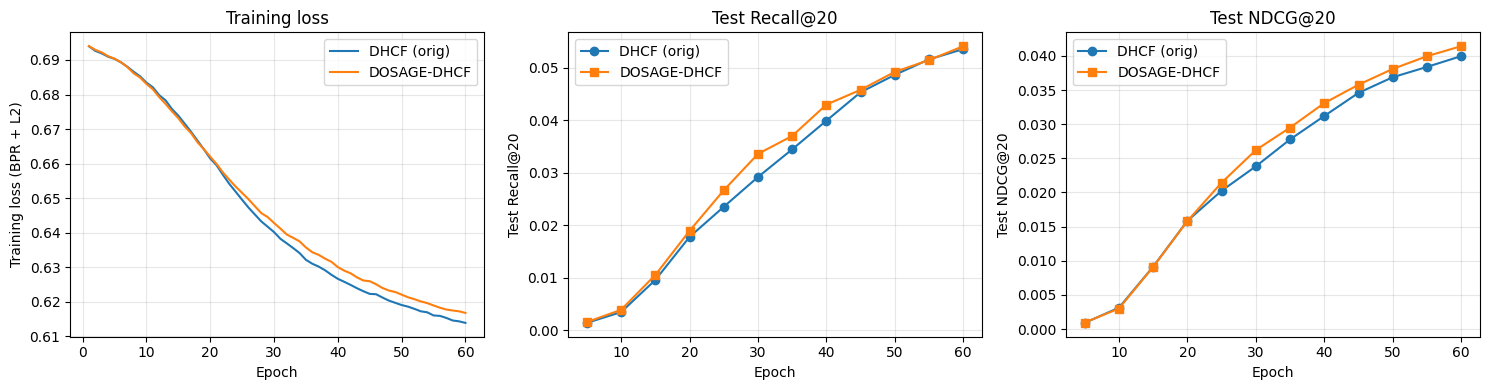

Saved /kaggle/working/citeulike_curves.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].plot(range(1, len(hist_orig['epoch_loss'])+1), hist_orig['epoch_loss'], label='DHCF (orig)', color='C0')
axes[0].plot(range(1, len(hist_dos['epoch_loss'])+1),  hist_dos['epoch_loss'],  label='DOSAGE-DHCF', color='C1')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training loss (BPR + L2)')
axes[0].set_title('Training loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Recall@20 over epochs
axes[1].plot(hist_orig['eval_eps'], hist_orig['R20'], 'o-', label='DHCF (orig)', color='C0')
axes[1].plot(hist_dos['eval_eps'],  hist_dos['R20'],  's-', label='DOSAGE-DHCF', color='C1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Recall@20')
axes[1].set_title('Test Recall@20'); axes[1].legend(); axes[1].grid(alpha=0.3)

# NDCG@20 over epochs
axes[2].plot(hist_orig['eval_eps'], hist_orig['N20'], 'o-', label='DHCF (orig)', color='C0')
axes[2].plot(hist_dos['eval_eps'],  hist_dos['N20'],  's-', label='DOSAGE-DHCF', color='C1')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Test NDCG@20')
axes[2].set_title('Test NDCG@20'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/citeulike_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved /kaggle/working/citeulike_curves.png')


## Notes

- **Eval matches DHCF paper:** full-ranking Recall@K and NDCG@K for K ∈ {10, 20, 50}.
- **Two variants only** to keep the run tight: DHCF baseline + one DOSAGE config (stats-matching, the best from ML-100K work).
- **CiteULike-A is sparser than ML-100K** — that's why `MIN_SHARED=2` (only 2 shared papers needed for an edge in the user-user graph). KNN-augment ensures no isolated nodes.
- **If DOSAGE config B underperforms**, swap to a smaller-hyperedge config: `dict(k=300, lam=2, alpha=3, beta=15, trials=50, phase2_extra=100)`.